# Training curves from `.qlog` files

Parses per-epoch train/val loss (and mae/r2) out of the `logs/train_*.qlog` files and plots them.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOGS_DIR = Path("..") / "logs"

EPOCH_RE = re.compile(
    r"epoch\s+(\d+)\s*\|\s*"
    r"train loss\s+(nan|[\d.]+)\s+mae\s+(nan|[\d.]+)\s+r2\s+(nan|-?[\d.]+)\s*\|\s*"
    r"val loss\s+(nan|[\d.]+)\s+mae\s+(nan|[\d.]+)\s+r2\s+(nan|-?[\d.]+)"
)


def parse_qlog(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        match = EPOCH_RE.search(line)
        if not match:
            continue
        epoch, train_loss, train_mae, train_r2, val_loss, val_mae, val_r2 = match.groups()
        rows.append(
            {
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "train_mae": float(train_mae),
                "train_r2": float(train_r2),
                "val_loss": float(val_loss),
                "val_mae": float(val_mae),
                "val_r2": float(val_r2),
            }
        )
    return pd.DataFrame(rows)

In [2]:
qlog_paths = sorted(LOGS_DIR.glob("train_*.qlog"))

runs = {}
for path in qlog_paths:
    model_name = path.name.split(".")[0].removeprefix("train_")
    df = parse_qlog(path)
    if df.empty:
        print(f"no epoch lines found in {path.name}, skipping")
        continue
    runs[model_name] = df
    print(f"{model_name}: {len(df)} epochs parsed from {path.name}")

CNN: 50 epochs parsed from train_CNN.6788525.qlog
CNN: 55 epochs parsed from train_CNN.6833634.qlog
LSTM: 50 epochs parsed from train_LSTM.6788522.qlog
LSTM: 144 epochs parsed from train_LSTM.6797076.qlog


## Train vs. val loss per model

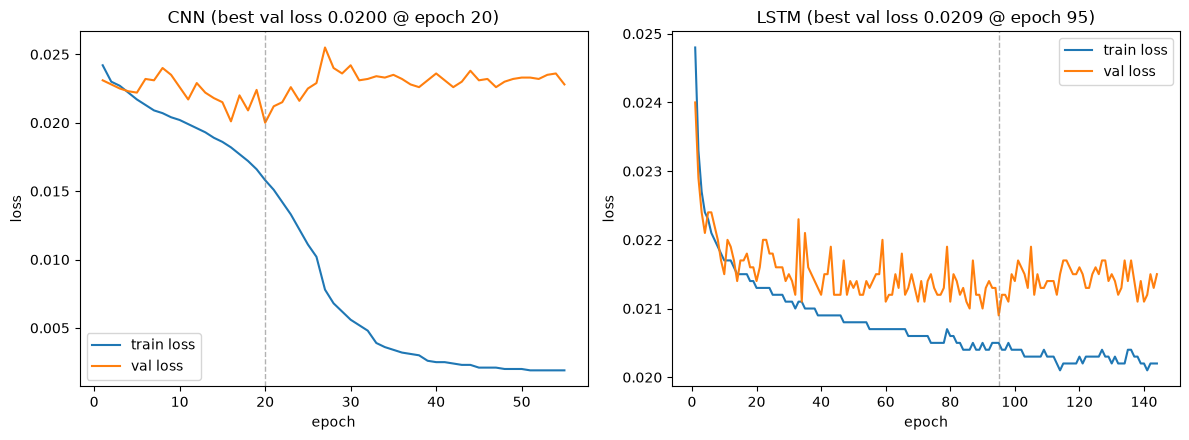

In [3]:
fig, axes = plt.subplots(1, len(runs), figsize=(6 * len(runs), 4.5), squeeze=False)

for ax, (model_name, df) in zip(axes[0], runs.items()):
    ax.plot(df["epoch"], df["train_loss"], label="train loss")
    ax.plot(df["epoch"], df["val_loss"], label="val loss")
    best_epoch = df.loc[df["val_loss"].idxmin()]
    ax.axvline(best_epoch["epoch"], color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{model_name} (best val loss {best_epoch['val_loss']:.4f} @ epoch {int(best_epoch['epoch'])})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()

fig.tight_layout()
plt.show()

## Val loss comparison across models

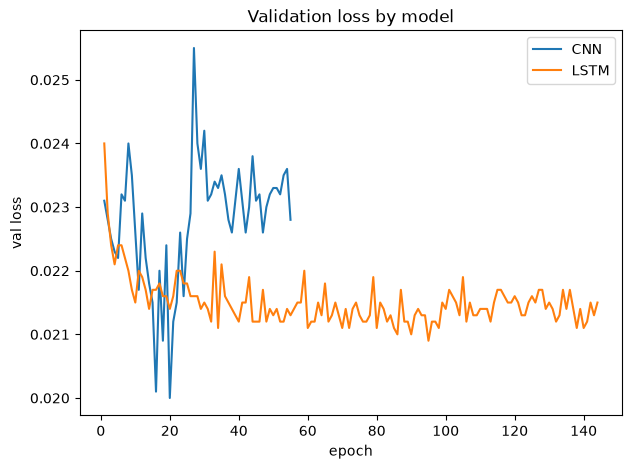

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name, df in runs.items():
    ax.plot(df["epoch"], df["val_loss"], label=model_name)

ax.set_xlabel("epoch")
ax.set_ylabel("val loss")
ax.set_title("Validation loss by model")
ax.legend()
plt.show()